# 20. AI Hub 경구약제 이미지 EDA (T1-1)

**데이터 출처**: AI Hub (https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=576)  
> ⚠️ 신청 승인 후 다운로드 가능 (1~5 영업일 소요). 다운로드 전에는 구조 파악 셀만 실행.

**파이프라인 역할**: YOLOv8 + CNN 주요 학습 데이터셋

## EDA 체크리스트
- [ ] 실제 클래스 수 vs. 공표 5,000종
- [ ] 클래스별 이미지 수 분포 (p10, p50, p90, min, max) — 모델링 핵심 수치
- [ ] 어노테이션 포맷 확인 (YOLO/COCO/PascalVOC)
- [ ] 단일 vs. 다중 알약 scene 비율
- [ ] 클래스 레이블 → 품목일련번호 변환 가능 여부
- [ ] 해상도 분포 / 배경 다양성
- [ ] 산출물: `data/interim/aihub_pills_summary.json`

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

ROOT = Path("../../").resolve()
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"

# AI Hub 다운로드 후 압축 해제 경로를 여기에 설정
AIHUB_ROOT = RAW / "aihub_pills"
print("AI Hub 데이터 경로:", AIHUB_ROOT)
print("존재 여부:", AIHUB_ROOT.exists())

AI Hub 데이터 경로: /Users/zzuhyeong2/Documents/Tobig's 25th/Conference/Pilliot_tobigs_conference_24_25/data/raw/aihub_pills
존재 여부: True


In [2]:
if not AIHUB_ROOT.exists():
    print("⚠️ 데이터 없음 — AI Hub 신청/다운로드 후 재실행")
    print("신청 URL: https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=576")
else:
    # 디렉토리 구조 확인
    for p in sorted(AIHUB_ROOT.rglob("*"))[:50]:
        print(p.relative_to(AIHUB_ROOT))

1.Training
1.Training/라벨링데이터
1.Training/라벨링데이터/경구약제조합_5000종
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000250
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000250/K-000250-000573-002483-006192_0_2_0_2_70_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000250/K-000250-000573-002483-006192_0_2_0_2_75_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000250/K-000250-000573-002483-006192_0_2_0_2_90_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000573
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000573/K-000250-000573-002483-006192_0_2_0_2_70_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000573/K-000250-000573-002483-006192_0_2_0_2_75_000_200.json
1.Training/라벨링데이터/경구약제조합_5000종/K-000250-000573-002483-006192_json/K-000573/K-00

Total images: 2,012
Total classes: 503
Images per class:
count    503.0
mean       4.0
std        0.0
min        4.0
25%        4.0
50%        4.0
75%        4.0
max        4.0


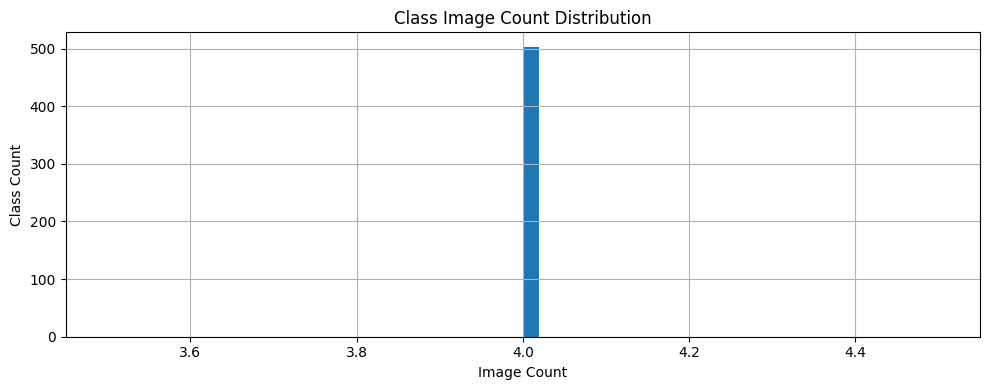

p10: 4 / p50: 4 / p90: 4
Single-image classes: 0


In [3]:
# 이미지 파일 목록 수집
TRAIN_IMAGE = AIHUB_ROOT / "1.Training" / "원천데이터"
if TRAIN_IMAGE.exists():
    img_paths = list(TRAIN_IMAGE.rglob("*.jpg")) + list(TRAIN_IMAGE.rglob("*.png"))
    print(f"Total images: {len(img_paths):,}")

    class_counts = Counter(p.parent.name for p in img_paths)
    print(f"Total classes: {len(class_counts):,}")

    if class_counts:
        counts_series = pd.Series(class_counts)
        print("Images per class:")
        print(counts_series.describe().to_string())

        counts_series.hist(bins=50, figsize=(10, 4))
        plt.title("Class Image Count Distribution")
        plt.xlabel("Image Count")
        plt.ylabel("Class Count")
        plt.tight_layout()
        plt.show()

        print(f"p10: {counts_series.quantile(0.1):.0f} / p50: {counts_series.quantile(0.5):.0f} / p90: {counts_series.quantile(0.9):.0f}")
        print(f"Single-image classes: {(counts_series <= 1).sum():,}")
    else:
        print("No images found — check TRAIN_IMAGE path")

In [4]:
# 어노테이션 파일 구조 확인
if AIHUB_ROOT.exists():
    json_files = list(AIHUB_ROOT.rglob("*.json"))
    txt_files  = list(AIHUB_ROOT.rglob("*.txt"))
    xml_files  = list(AIHUB_ROOT.rglob("*.xml"))
    print(f"json: {len(json_files):,} / txt: {len(txt_files):,} / xml: {len(xml_files):,}")

    # 샘플 어노테이션 파싱
    if json_files:
        with open(json_files[0], encoding="utf-8") as f:
            ann = json.load(f)
        print("JSON 최상위 키:", list(ann.keys()))

json: 2,663,396 / txt: 0 / xml: 0
JSON 최상위 키: ['images', 'type', 'annotations', 'categories']


In [5]:
# 클래스 레이블 → 품목일련번호 변환 가능 여부 확인
if AIHUB_ROOT.exists():
    sample_class_names = list(class_counts.keys())[:10]
    print("샘플 클래스 레이블:")
    for name in sample_class_names:
        print(" ", name)
    print("\n품목일련번호(숫자 9자리) 패턴 여부:")
    import re
    is_seq = [bool(re.match(r'^\d{9}$', name)) for name in sample_class_names]
    print(f"  직접 변환 가능: {sum(is_seq)}/{len(is_seq)}")

샘플 클래스 레이블:
  K-001866-004378-012778-038954
  K-001866-002483-012081-012778
  K-000250-000573-012778-038954
  K-000250-022362-023223-037777
  K-001866-005886-022627-037777
  K-000250-002483-012778-013395
  K-001866-013395-022627-037777
  K-001900-004543-016548-044199
  K-001866-005002-022362-023223
  K-000573-023223-025438-044834

품목일련번호(숫자 9자리) 패턴 여부:
  직접 변환 가능: 0/10


In [6]:
# 해상도 분포 (샘플 500장)
if AIHUB_ROOT.exists():
    try:
        from PIL import Image
        import random
        sample_imgs = random.sample(img_paths, min(500, len(img_paths)))
        sizes = []
        for p in sample_imgs:
            try:
                with Image.open(p) as im:
                    sizes.append(im.size)
            except Exception:
                pass
        df_sizes = pd.DataFrame(sizes, columns=["width", "height"])
        print(df_sizes.describe().to_string())
    except ImportError:
        print("Pillow 미설치 — !pip install Pillow")

       width  height
count  500.0   500.0
mean   976.0  1280.0
std      0.0     0.0
min    976.0  1280.0
25%    976.0  1280.0
50%    976.0  1280.0
75%    976.0  1280.0
max    976.0  1280.0


Parsing JSON Annotations (Sample size: 1,000)...
Extracted Individual Pills: 1,000
Unique Pill Classes: 1


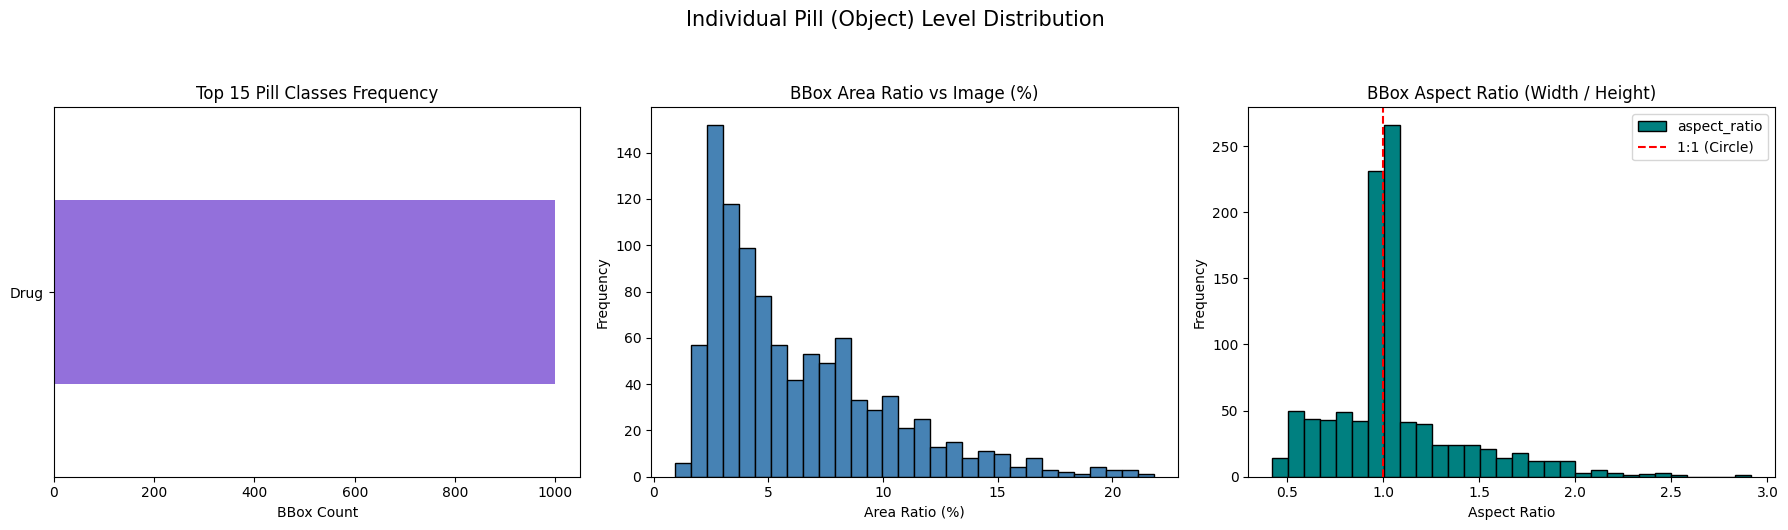

In [13]:
import json
import random
import pandas as pd
import matplotlib.pyplot as plt

if AIHUB_ROOT.exists() and json_files:
    print("Parsing JSON Annotations (Sample size: 1,000)...")
    
    # 빠른 EDA를 위해 최대 1,000개의 JSON만 무작위 샘플링
    sample_jsons = random.sample(json_files, min(1000, len(json_files)))
    
    individual_pills = []
    bbox_stats = []

    for j_path in sample_jsons:
        try:
            with open(j_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            
            # 이미지 해상도 추출 (Area 계산용)
            img_width = data.get('images', [{}])[0].get('width', 976)
            img_height = data.get('images', [{}])[0].get('height', 1280)
            img_area = img_width * img_height
            
            # 카테고리 ID -> 품목일련번호(name) 매핑
            cat_map = {cat['id']: cat.get('name', 'Unknown') for cat in data.get('categories', [])}
            
            for ann in data.get('annotations', []):
                # 1. 개별 품목코드 추출
                cat_id = ann.get('category_id')
                pill_code = cat_map.get(cat_id, 'Unknown')
                individual_pills.append(pill_code)
                
                # 2. BBox [x, y, width, height] (COCO 포맷 기준)
                bbox = ann.get('bbox', [0, 0, 0, 0])
                if len(bbox) == 4:
                    w, h = bbox[2], bbox[3]
                    area = w * h
                    # 전체 이미지 대비 알약이 차지하는 면적 비율 (%)
                    area_ratio = (area / img_area) * 100 if img_area > 0 else 0
                    # 가로/세로 비율 (1에 가까울수록 원형/정사각형)
                    aspect_ratio = w / h if h > 0 else 0
                    
                    bbox_stats.append({
                        'width': w, 'height': h,
                        'area_ratio': area_ratio,
                        'aspect_ratio': aspect_ratio
                    })
        except Exception as e:
            continue

    df_pills = pd.Series(individual_pills)
    df_bbox = pd.DataFrame(bbox_stats)

    print(f"Extracted Individual Pills: {len(df_pills):,}")
    print(f"Unique Pill Classes: {df_pills.nunique():,}")

    # --- 시각화 (영문 적용) ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. 개별 알약 출현 빈도 Top 15 (Class Imbalance 확인)
    df_pills.value_counts().head(15).sort_values().plot(
        kind='barh', ax=axes[0], color='mediumpurple'
    )
    axes[0].set_title('Top 15 Pill Classes Frequency')
    axes[0].set_xlabel('BBox Count')

    # 2. BBox 면적 비율 분포 (Small Object 여부 확인)
    if not df_bbox.empty:
        df_bbox['area_ratio'].plot(kind='hist', bins=30, ax=axes[1], color='steelblue', edgecolor='black')
        axes[1].set_title('BBox Area Ratio vs Image (%)')
        axes[1].set_xlabel('Area Ratio (%)')
        
    # 3. BBox 종횡비 분포 (알약 형태 추정)
    if not df_bbox.empty:
        df_bbox['aspect_ratio'].plot(kind='hist', bins=30, ax=axes[2], color='teal', edgecolor='black')
        axes[2].axvline(1.0, color='red', linestyle='dashed', label='1:1 (Circle)')
        axes[2].set_title('BBox Aspect Ratio (Width / Height)')
        axes[2].set_xlabel('Aspect Ratio')
        axes[2].legend()

    plt.suptitle('Individual Pill (Object) Level Distribution', y=1.05, fontsize=15)
    plt.tight_layout()
    plt.show()
else:
    print("No JSON files found. Skipping analysis.")

Generating BBox Inspection Gallery...


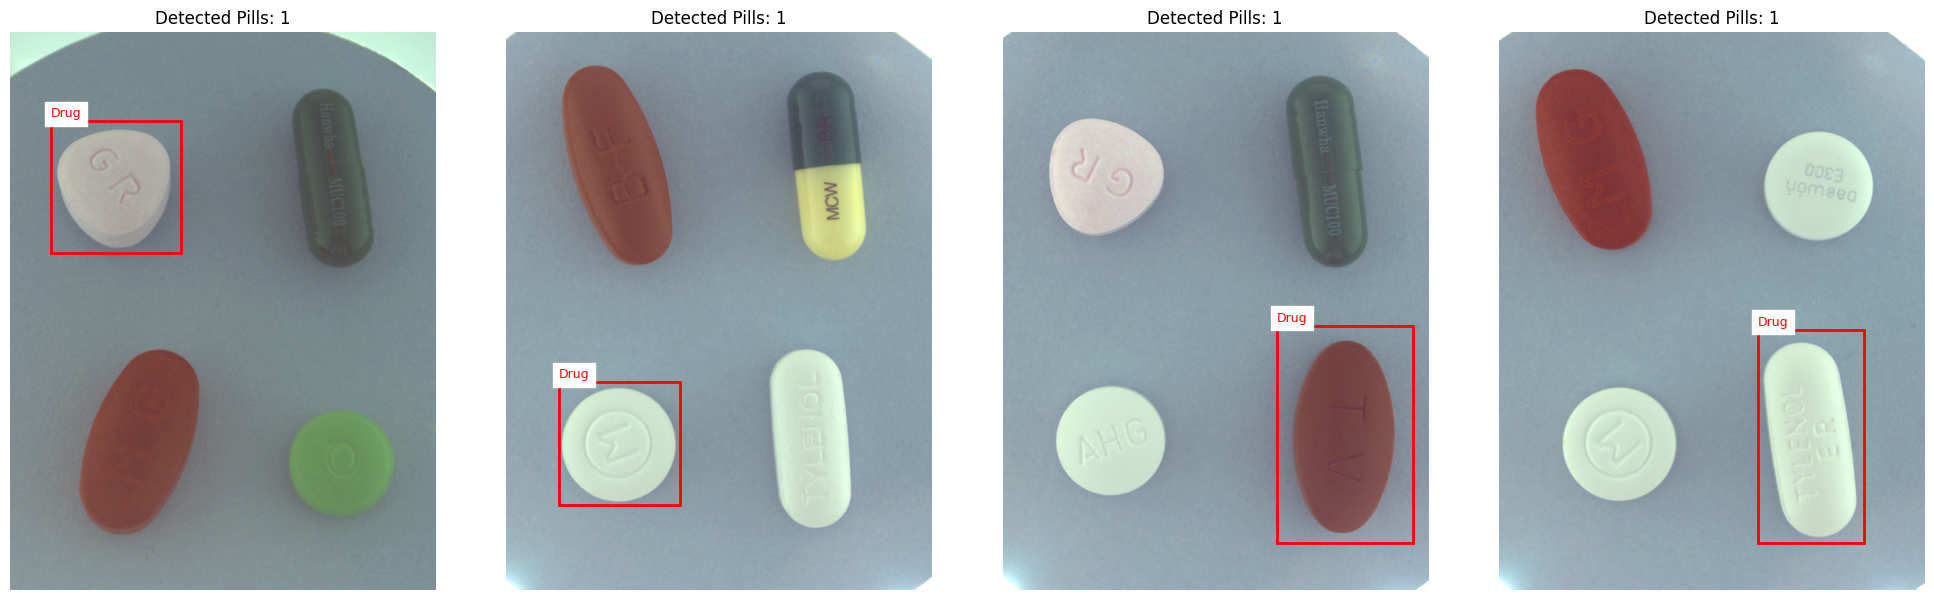

In [10]:
import matplotlib.patches as patches
from PIL import Image

if AIHUB_ROOT.exists() and json_files and img_paths:
    print("Generating BBox Inspection Gallery...")
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    
    matched_pairs = []
    random_imgs = random.sample(img_paths, min(100, len(img_paths)))
    
    for img_p in random_imgs:
        expected_json_name = img_p.stem + ".json"
        matching_jsons = [j for j in json_files if j.name == expected_json_name]
        
        if matching_jsons:
            matched_pairs.append((img_p, matching_jsons[0]))
        if len(matched_pairs) >= 4:
            break
            
    for ax, (img_p, json_p) in zip(axes, matched_pairs):
        try:
            im = Image.open(img_p)
            ax.imshow(im)
            
            with open(json_p, "r", encoding="utf-8") as f:
                data = json.load(f)
                
            cat_map = {}
            for cat in data.get('categories', []):
                cat_map[cat.get('id')] = cat.get('name') or cat.get('category_name') or str(cat.get('id'))
            
            for ann in data.get('annotations', []):
                # 라벨 파싱 로직 (1번 셀과 동일하게 강화)
                label = "Unknown"
                for key in ['name', 'class_name', 'label']:
                    if key in ann:
                        label = str(ann[key])
                        break
                if label == "Unknown":
                    cat_id = ann.get('category_id') or ann.get('class')
                    label = cat_map.get(cat_id, json_p.parent.name)
                
                bbox = ann.get('bbox', [0, 0, 0, 0])
                if len(bbox) == 4:
                    x, y, w, h = bbox
                    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
                    
                    ax.text(x, y - 10, label, color='red', fontsize=9, backgroundcolor='white')
                    
            ax.set_title(f"Detected Pills: {len(data.get('annotations', []))}")
            ax.axis('off')
        except Exception as e:
            ax.set_title("Loading Error")
            ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient files to generate gallery.")

In [ ]:
import json

# 산출물 저장 (덮어쓰기)
if AIHUB_ROOT.exists():
    summary = {
        "total_images": len(img_paths) if 'img_paths' in locals() else 0,
        "total_scene_classes": len(class_counts) if 'class_counts' in locals() else 0,
        "images_per_class_p10": float(counts_series.quantile(0.1)) if 'counts_series' in locals() else 0.0,
        "images_per_class_median": float(counts_series.median()) if 'counts_series' in locals() else 0.0,
        "images_per_class_p90": float(counts_series.quantile(0.9)) if 'counts_series' in locals() else 0.0,
    }
    
    # 1번 셀(BBox 분석)이 성공적으로 돌아서 데이터프레임이 존재한다면 통계 추가
    if 'df_pills' in locals() and 'df_bbox' in locals() and not df_bbox.empty:
        summary["bbox_stats"] = {
            "unique_individual_pills": int(df_pills.nunique()),
            "bbox_avg_area_ratio_pct": round(float(df_bbox['area_ratio'].mean()), 2),
            "bbox_avg_aspect_ratio": round(float(df_bbox['aspect_ratio'].mean()), 2)
        }
    
    # EDA를 통해 발견한 가장 중요한 구조적 특징 메모
    summary["note"] = (
        "이미지 1장에 여러 알약이 존재하나, JSON 정답지는 알약 개수만큼 분할되어 "
        "각각 다른 폴더에 1개의 BBox만 담긴 채 저장되는 비표준 구조. "
        "YOLOv8 파이프라인 연동 시, 동일한 이미지 이름을 가진 JSON 파일들을 "
        "전부 긁어모아 1개의 .txt 파일로 병합(Merge)하는 전처리 로직이 반드시 필요함."
    )

    out_path = INTERIM / "aihub_pills_summary.json"
    
    # 'w' 모드로 열어서 기존 내용 덮어쓰기
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print(f'저장 완료: {out_path}')
    print(json.dumps(summary, ensure_ascii=False, indent=2))
else:
    print("데이터 없음 — 다운로드 후 재실행")

In [11]:
import json

# 산출물 저장
if AIHUB_ROOT.exists():
    summary = {
        "total_images": len(img_paths),
        "total_classes": len(class_counts),
        "images_per_class_p10": float(counts_series.quantile(0.1)),
        "images_per_class_median": float(counts_series.median()),
        "images_per_class_p90": float(counts_series.quantile(0.9)),
    }
    
    # 1번 셀(BBox 분석)이 실행되었다면 통계 및 메모 추가
    if 'df_pills' in locals() and 'df_bbox' in locals() and not df_bbox.empty:
        summary.update({
            "unique_individual_pills": int(df_pills.nunique()),
            "bbox_avg_area_ratio_pct": round(float(df_bbox['area_ratio'].mean()), 2),
            "bbox_avg_aspect_ratio": round(float(df_bbox['aspect_ratio'].mean()), 2),
            "note": "이미지 1장에 여러 알약이 존재하나, JSON은 알약 개수만큼 분할되어 각각 다른 폴더에 1개의 BBox만 담긴 구조. YOLOv8 연동 시 동일 이미지의 JSON들을 1개의 .txt로 병합(Merge)하는 전처리 필수."
        })

    with open(INTERIM / "aihub_pills_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
        
    print(json.dumps(summary, ensure_ascii=False, indent=2))
else:
    print("데이터 없음 — 다운로드 후 재실행")

{
  "total_images": 2012,
  "total_classes": 503,
  "images_per_class_p10": 4.0,
  "images_per_class_median": 4.0,
  "images_per_class_p90": 4.0,
  "unique_individual_pills": 1,
  "bbox_avg_area_ratio_pct": 6.22,
  "bbox_avg_aspect_ratio": 1.07,
  "note": "이미지 1장에 여러 알약이 존재하나, JSON은 알약 개수만큼 분할되어 각각 다른 폴더에 1개의 BBox만 담긴 구조. YOLOv8 연동 시 동일 이미지의 JSON들을 1개의 .txt로 병합(Merge)하는 전처리 필수."
}
